# Spatial interpolation using predicted and true values

This notebook builds a spatial interpolation map for a single timestep using model predictions and evaluates against spatial holdout wells.

Notes:
- For Kriging-style interpolation the `GaussianProcessRegressor` was used
- Inputs are first predicted values, and then true values, at the same time horizon


In [43]:
from pathlib import Path

ROOT = Path(".").resolve()
for p in [ROOT, *ROOT.parents]:
    if (p / "configs" / "data.yaml").exists():
        ROOT = p
        break

In [44]:
import sys
import numpy as np
import pandas as pd
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import json
from pyproj import Transformer
from matplotlib.colors import TwoSlopeNorm
import pyarrow.parquet as pq



from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler


In [45]:
ROOT = Path('.').resolve()
for p in [ROOT, *ROOT.parents]:
    if (p / 'configs' / 'data.yaml').exists():
        ROOT = p
        break

SRC_ROOT = ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

DATASET = 'full_merged'
PRED_PATH = ROOT / 'outputs' / 'TFT' / 'TFT_in52_out16_ep50_bs4096_stat1_seed40_full_merged' / 'predictions' / 'pred.parquet'
HORIZON = 16
GRID_NX = 200
GRID_NY = 200

data_cfg = yaml.safe_load((ROOT / 'configs' / 'data.yaml').read_text(encoding='utf-8')) or {}
for key in ['full_raw_path', 'metadata_path', 'full_merged_path', 'sample_path']:
    if key in data_cfg and data_cfg[key]:
        p = Path(data_cfg[key])
        data_cfg[key] = str(p if p.is_absolute() else (ROOT / p).resolve())

DATA_PATH = Path(data_cfg['full_merged_path'])


In [46]:
def load_dataset(path, cols=None):
    path = str(path)
    if path.lower().endswith(".csv"):
        return pd.read_csv(path, usecols=cols, low_memory=False)
    return pq.read_table(path, columns=cols).to_pandas()

cols = ["datum", "id", "gws", "x_25833", "y_25833"]
gws = load_dataset(DATA_PATH, cols=cols)
gws["datum"] = pd.to_datetime(gws["datum"])

last_date = gws["datum"].max()
last_date


Timestamp('2024-06-03 00:00:00')

In [47]:
# Spatial split
split_path = ROOT / "outputs" / f"spatial_split_{DATASET}.csv"
split = pd.read_csv(split_path)
train_ids = set(split.loc[split["spatial_split"] == "spatial_train", "id"])
holdout_ids = set(split.loc[split["spatial_split"] == "spatial_holdout", "id"])

coords = gws[["id", "x_25833", "y_25833"]].drop_duplicates("id")

In [48]:
# True values at the last date
gws_last = gws[gws["datum"] == last_date][["id", "gws"]].merge(coords, on="id", how="left")

holdout_true = gws_last[gws_last["id"].isin(holdout_ids)].dropna()
train_true = gws_last[gws_last["id"].isin(train_ids)].dropna()

len(train_true), len(holdout_true)

(841, 199)

In [49]:
pred = pd.read_parquet(PRED_PATH)
pred["datum"] = pd.to_datetime(pred["datum"])
pred["startzeitpunkt"] = pd.to_datetime(pred["startzeitpunkt"])

train_all = gws[gws["id"].isin(train_ids)]
ids_all = pd.unique(train_all["id"])
lookup = pd.DataFrame({"id": ids_all}).reset_index()

pred = pred.merge(lookup, on="index", how="left")

pred["horizon"] = ((pred["datum"] - pred["startzeitpunkt"]) / pd.Timedelta(weeks=1)) + 1
pred_last = pred[(pred["datum"] == last_date) & (pred["horizon"] == HORIZON)].copy()

pred_last = pred_last.rename(columns={"gws": "gws_pred"})
pred_last = pred_last.merge(coords, on="id", how="left")

pred_last.head()


,datum,gws_pred,index,startzeitpunkt,id,horizon,x_25833,y_25833
0,2024-06-03,78.791504,0,2024-02-19,LFU_25470023,16.0,409854.0,5919495.0
1,2024-06-03,78.209488,1,2024-02-19,LFU_25470024,16.0,409856.0,5919494.0
2,2024-06-03,34.665306,2,2024-02-19,LFU_25480025,16.0,422075.0,5923197.0
3,2024-06-03,80.572266,3,2024-02-19,LFU_25480026,16.0,412183.0,5923933.0
4,2024-06-03,36.600857,4,2024-02-19,LFU_25481088,16.0,421783.0,5925854.0


In [50]:
train_pred = pred_last[pred_last["id"].isin(train_ids)].dropna(subset=["gws_pred", "x_25833", "y_25833"])

X_train = train_pred[["x_25833", "y_25833"]].values
y_train = train_pred["gws_pred"].values

holdout_eval = holdout_true.copy()
X_holdout = holdout_eval[["x_25833", "y_25833"]].values
y_holdout = holdout_eval["gws"].values

len(X_train), len(X_holdout)


(841, 199)

In [51]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_holdout_s = scaler.transform(X_holdout)

kernel = ConstantKernel(1.0, (1e-2, 1e3)) * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=1e-3)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=2,
)

gpr.fit(X_train_s, y_train)

y_pred_holdout = gpr.predict(X_holdout_s)
y_pred_train = gpr.predict(X_train_s)

train_err = np.abs(y_pred_train - y_train)
holdout_err = np.abs(y_pred_holdout - y_holdout)
err_max = float(max(train_err.max(), holdout_err.max())) if len(train_err) and len(holdout_err) else 1.0
if err_max == 0:
    err_max = 1.0

rmse = float(np.sqrt(np.mean((y_pred_holdout - y_holdout) ** 2)))
nse = float(1 - np.sum((y_pred_holdout - y_holdout) ** 2) / np.sum((y_holdout - y_holdout.mean()) ** 2))

rmse, nse


(5.139085439241235, 0.9447949950374251)

In [52]:
xmin, xmax = coords["x_25833"].min(), coords["x_25833"].max()
ymin, ymax = coords["y_25833"].min(), coords["y_25833"].max()

xs = np.linspace(xmin, xmax, GRID_NX)
ys = np.linspace(ymin, ymax, GRID_NY)
xx, yy = np.meshgrid(xs, ys)

X_grid = np.column_stack([xx.ravel(), yy.ravel()])
X_grid_s = scaler.transform(X_grid)

z = gpr.predict(X_grid_s).reshape(xx.shape)


In [53]:
BOUNDARY_PATH = ROOT / "data" / "boundaries" / "geoBoundaries-DEU-ADM1_simplified.geojson"
assert BOUNDARY_PATH.exists(), f"Missing: {BOUNDARY_PATH}"
BOUNDARY_NAMES = {"Berlin", "Brandenburg"}

def _rings(path, names):
    data = json.load(open(path))
    feats = [
        f for f in data.get("features", [])
        if f.get("properties", {}).get("shapeName") in names
    ]
    if not feats:
        return []
    tr = Transformer.from_crs("EPSG:4326", "EPSG:25833", always_xy=True)
    rings = []
    for feat in feats:
        geom = feat.get("geometry", {})
        gtype = geom.get("type")
        coords = geom.get("coordinates", [])
        polys = [coords] if gtype == "Polygon" else coords if gtype == "MultiPolygon" else []
        for poly in polys:
            for ring in poly:
                xs, ys = zip(*[tr.transform(lon, lat) for lon, lat in ring])
                rings.append((list(xs), list(ys)))
    return rings

boundary_rings = _rings(BOUNDARY_PATH, BOUNDARY_NAMES)

def plot_admin_boundaries(ax, rings, **kwargs):
    for xs, ys in rings:
        ax.plot(xs, ys, **kwargs)


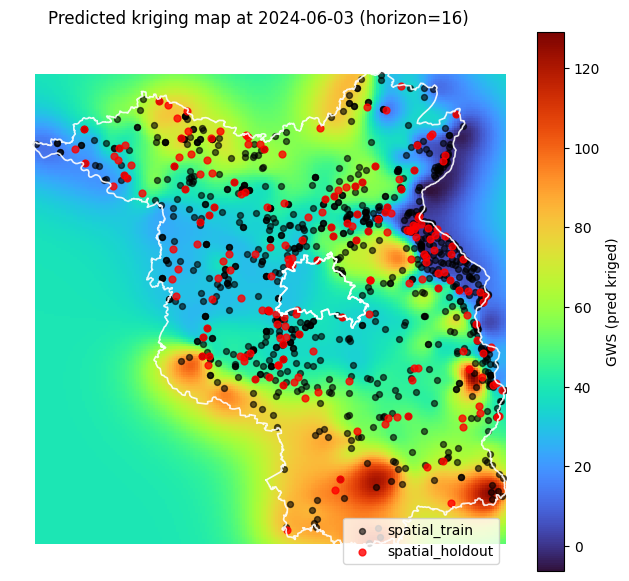

In [54]:
vmin_pred = float(np.nanmin(z))
vmax_pred = float(np.nanmax(z))
norm_pred = plt.Normalize(vmin=vmin_pred, vmax=vmax_pred)

fig, ax = plt.subplots(figsize=(8, 7))
cf = ax.pcolormesh(xx, yy, z, shading="auto", cmap="turbo", norm=norm_pred)
plt.colorbar(cf, ax=ax, label="GWS (pred kriged)")

plot_admin_boundaries(ax, boundary_rings, color="white", linewidth=1.2, alpha=0.9)



ax.scatter(
    train_pred["x_25833"],
    train_pred["y_25833"],
    s=18,
    c="black",
    label="spatial_train",
    alpha=0.6,
)
ax.scatter(
    holdout_eval["x_25833"],
    holdout_eval["y_25833"],
    s=24,
    c="red",
    label="spatial_holdout",
    alpha=0.8,
)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"Predicted kriging map at {last_date.date()} (horizon={HORIZON})")
ax.legend(loc="lower right")



Text(0.5, 1.0, 'Holdout errors at 2024-06-03 (horizon=16)\n(dot size corresponding to absolute kriging error)')

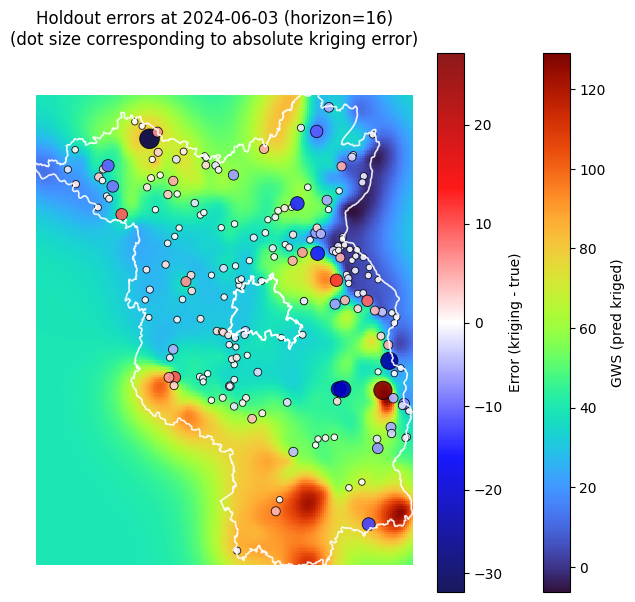

In [55]:
holdout_cmp = holdout_eval[["id", "gws", "x_25833", "y_25833"]].copy()
holdout_cmp["gws_kriged"] = y_pred_holdout
holdout_cmp["err"] = holdout_cmp["gws_kriged"] - holdout_cmp["gws"]
holdout_cmp["abs_err"] = holdout_cmp["err"].abs()

min_size = 20
max_size = 200
err_abs = holdout_cmp["abs_err"].values
if err_abs.max() == err_abs.min():
    sizes = np.full_like(err_abs, (min_size + max_size) / 2.0, dtype=float)
else:
    sizes = min_size + (err_abs - err_abs.min()) * (max_size - min_size) / (err_abs.max() - err_abs.min())

fig2, ax2 = plt.subplots(figsize=(8, 7))
cf2 = ax2.pcolormesh(xx, yy, z, shading="auto", cmap="turbo", norm=norm_pred)
plt.colorbar(cf2, ax=ax2, label="GWS (pred kriged)")

plot_admin_boundaries(ax2, boundary_rings, color="white", linewidth=1.2, alpha=0.9)



norm_err = TwoSlopeNorm(vcenter=0.0, vmin=holdout_cmp["err"].min(), vmax=holdout_cmp["err"].max())

sc = ax2.scatter(
    holdout_cmp["x_25833"],
    holdout_cmp["y_25833"],
    s=sizes,
    c=holdout_cmp["err"],
    cmap="seismic",
    norm=norm_err,
    edgecolors="black",
    linewidths=0.6,
    alpha=0.9,
)
plt.colorbar(sc, ax=ax2, label="Error (kriging - true)")

for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title(f"Holdout errors at {last_date.date()} (horizon={HORIZON})\n(dot size corresponding to absolute kriging error)")

In [56]:
holdout_cmp = holdout_eval[["id", "gws", "x_25833", "y_25833"]].copy()
holdout_cmp["gws_kriged"] = y_pred_holdout
holdout_cmp["diff"] = holdout_cmp["gws_kriged"] - holdout_cmp["gws"]  # prediction - truth

holdout_cmp[holdout_cmp["diff"].abs()>10]


,id,gws,x_25833,y_25833,gws_kriged,diff
22,LFU_26490028,24.86,424515.00,5908178.0,14.291636,-10.568364
33,LFU_27390101,112.12,321176.00,5904496.0,79.856849,-32.263151
73,LFU_28370020,49.03,295525.00,5891075.0,38.748281,-10.281719
252,LFU_30481528,70.86,412549.00,5872191.0,57.014058,-13.845942
426,LFU_32492085,67.91,425081.00,5847239.0,53.332115,-14.577885
516,LFU_33502241,61.48,436809.00,5833855.0,72.451284,10.971284
808,LFU_37532730,62.34,469430.00,5793644.0,38.582696,-23.757304
874,LFU_38501726,60.43,438070.03,5779506.3,43.751864,-16.678136
877,LFU_38501758,67.02,440446.27,5779474.3,44.403414,-22.616586
882,LFU_38525106,83.47,465463.00,5778946.0,110.727602,27.257602


In [57]:
mean_diff = float(holdout_cmp["diff"].mean())
median_diff = float(holdout_cmp["diff"].median())

rmse = float(np.sqrt(np.mean((holdout_cmp["gws_kriged"] - holdout_cmp["gws"]) ** 2)))

baseline_mean = float(y_train.mean())
baseline_rmse = float(np.sqrt(np.mean((baseline_mean - holdout_cmp["gws"]) ** 2)))

sse = float(np.sum((holdout_cmp["gws_kriged"] - holdout_cmp["gws"]) ** 2))
sst = float(np.sum((baseline_mean - holdout_cmp["gws"]) ** 2))
nse = float(1 - sse / sst) if sst != 0 else np.nan

print(f"mean_diff:                      {mean_diff:.3f}")
print(f"median_diff:                    {median_diff:.3f}")
print(f"rmse:                            {rmse:.3f}")
print(f"baseline_rmse (mean predictor): {baseline_rmse:.3f}")
print(f"nse (vs mean predictor):         {nse:.3f}")

mean_diff:                      -0.598
median_diff:                    -0.097
rmse:                            5.139
baseline_rmse (mean predictor): 21.883
nse (vs mean predictor):         0.945


In [58]:
train_true_eval = train_true.dropna(subset=["gws", "x_25833", "y_25833"])
X_train_true = train_true_eval[["x_25833", "y_25833"]].values
y_train_true = train_true_eval["gws"].values

len(X_train_true)


841

In [59]:
scaler_true = StandardScaler()
X_train_true_s = scaler_true.fit_transform(X_train_true)
X_holdout_true_s = scaler_true.transform(X_holdout)

kernel_true = ConstantKernel(1.0, (1e-2, 1e3)) * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=1e-3)

gpr_true = GaussianProcessRegressor(
    kernel=kernel_true,
    normalize_y=True,
    n_restarts_optimizer=2,
)

gpr_true.fit(X_train_true_s, y_train_true)

y_pred_holdout_true = gpr_true.predict(X_holdout_true_s)
y_pred_train_true = gpr_true.predict(X_train_true_s)

train_err_true = np.abs(y_pred_train_true - y_train_true)
holdout_err_true = np.abs(y_pred_holdout_true - y_holdout)
err_max_true = float(max(train_err_true.max(), holdout_err_true.max())) if len(train_err_true) and len(holdout_err_true) else 1.0
if err_max_true == 0:
    err_max_true = 1.0

rmse_true = float(np.sqrt(np.mean((y_pred_holdout_true - y_holdout) ** 2)))
# NSE
nse_true = float(1 - np.sum((y_pred_holdout_true - y_holdout) ** 2) / np.sum((y_holdout - y_holdout.mean()) ** 2))

rmse_true, nse_true


(20.228493139627737, 0.14466972945187206)

In [60]:
X_grid_s_true = scaler_true.transform(X_grid)

z_true = gpr_true.predict(X_grid_s_true).reshape(xx.shape)


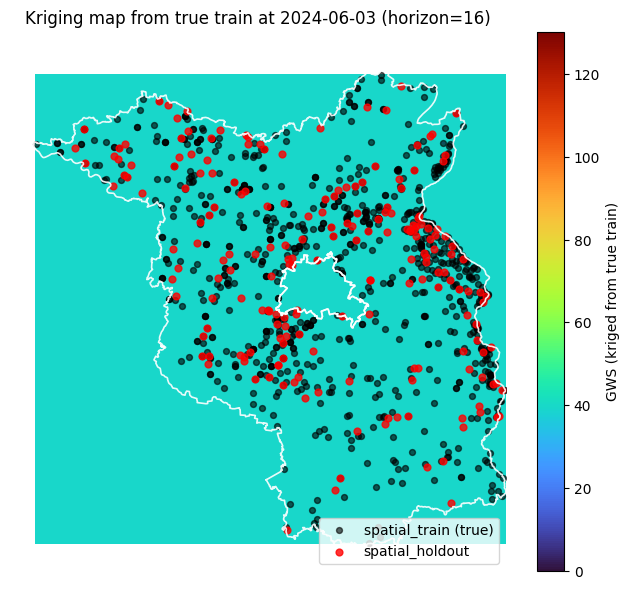

In [61]:
vmin_true = float(min(np.nanmin(z_true), np.nanmin(y_train_true), np.nanmin(y_holdout)))
vmax_true = float(max(np.nanmax(z_true), np.nanmax(y_train_true), np.nanmax(y_holdout)))
norm_true = plt.Normalize(vmin=vmin_true, vmax=vmax_true)

fig_true, ax_true = plt.subplots(figsize=(8, 7))
cf_true = ax_true.pcolormesh(xx, yy, z_true, shading="auto", cmap="turbo", norm=norm_true)
plt.colorbar(cf_true, ax=ax_true, label="GWS (kriged from true train)")

plot_admin_boundaries(ax_true, boundary_rings, color="white", linewidth=1.2, alpha=0.9)



ax_true.scatter(
    train_true_eval["x_25833"],
    train_true_eval["y_25833"],
    s=18,
    c="black",
    label="spatial_train (true)",
    alpha=0.6,
)
ax_true.scatter(
    holdout_eval["x_25833"],
    holdout_eval["y_25833"],
    s=24,
    c="red",
    label="spatial_holdout",
    alpha=0.8,
)


for spine in ax_true.spines.values():
    spine.set_visible(False)
ax_true.set_xticks([])
ax_true.set_yticks([])
ax_true.set_title(f"Kriging map from true train at {last_date.date()} (horizon={HORIZON})")
ax_true.legend(loc="lower right")


Text(0, 0.5, 'y_25833')

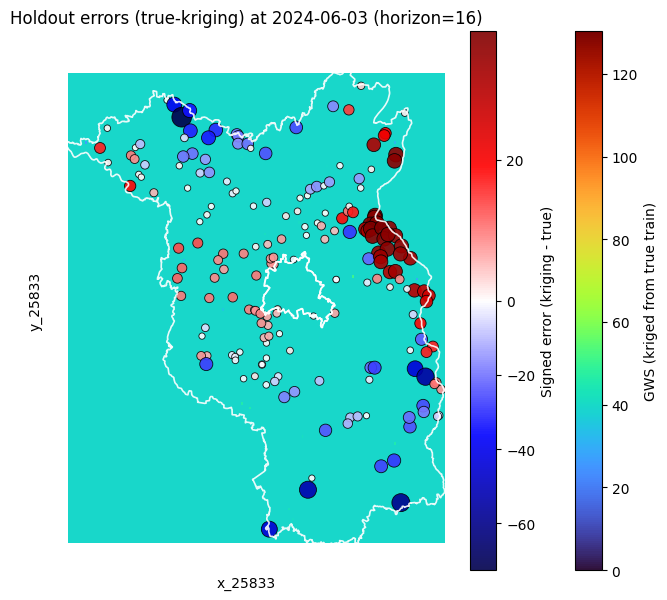

In [62]:
holdout_cmp_true = holdout_eval[["id", "gws", "x_25833", "y_25833"]].copy()
holdout_cmp_true["gws_kriged"] = y_pred_holdout_true
holdout_cmp_true["err"] = holdout_cmp_true["gws_kriged"] - holdout_cmp_true["gws"]
holdout_cmp_true["abs_err"] = holdout_cmp_true["err"].abs()

min_size = 20
max_size = 200
err_abs_true = holdout_cmp_true["abs_err"].values
if err_abs_true.max() == err_abs_true.min():
    sizes_true = np.full_like(err_abs_true, (min_size + max_size) / 2.0, dtype=float)
else:
    sizes_true = min_size + (err_abs_true - err_abs_true.min()) * (max_size - min_size) / (err_abs_true.max() - err_abs_true.min())

fig2_true, ax2_true = plt.subplots(figsize=(8, 7))
cf2_true = ax2_true.pcolormesh(xx, yy, z_true, shading="auto", cmap="turbo", norm=norm_true)
plt.colorbar(cf2_true, ax=ax2_true, label="GWS (kriged from true train)")

plot_admin_boundaries(ax2_true, boundary_rings, color="white", linewidth=1.2, alpha=0.9)



norm_err_true = TwoSlopeNorm(vcenter=0.0, vmin=holdout_cmp_true["err"].min(), vmax=holdout_cmp_true["err"].max())

sc_true = ax2_true.scatter(
    holdout_cmp_true["x_25833"],
    holdout_cmp_true["y_25833"],
    s=sizes_true,
    c=holdout_cmp_true["err"],
    cmap="seismic",
    norm=norm_err_true,
    edgecolors="black",
    linewidths=0.6,
    alpha=0.9,
)
plt.colorbar(sc_true, ax=ax2_true, label="Signed error (kriging - true)")

for spine in ax2_true.spines.values():
    spine.set_visible(False)
ax2_true.set_xticks([])
ax2_true.set_yticks([])
ax2_true.set_title(f"Holdout errors (true-kriging) at {last_date.date()} (horizon={HORIZON})")
ax2_true.set_xlabel("x_25833")
ax2_true.set_ylabel("y_25833")





In [63]:
holdout_cmp_true = holdout_eval[["id", "gws", "x_25833", "y_25833"]].copy()
holdout_cmp_true["gws_kriged"] = y_pred_holdout_true
holdout_cmp_true["diff"] = holdout_cmp_true["gws_kriged"] - holdout_cmp_true["gws"]  # prediction - truth

holdout_cmp_true[holdout_cmp_true["diff"].abs() > 10]


,id,gws,x_25833,y_25833,gws_kriged,diff
12,LFU_26390040,78.06,316596.00,5910794.00,39.378276,-38.681724
19,LFU_26480022,56.11,414784.00,5909950.00,39.378276,-16.731724
22,LFU_26490028,24.86,424515.00,5908178.00,39.378276,14.518276
33,LFU_27390101,112.12,321176.00,5904496.00,39.378276,-72.741724
34,LFU_27400050,73.03,326070.00,5907834.00,39.378276,-33.651724
...,...,...,...,...,...,...
999,LFU_42516181,68.19,452465.96,5733121.73,39.378276,-28.811724
1000,LFU_42517003,66.25,444466.00,5730252.00,39.378276,-26.871724
1013,LFU_43476151,92.18,399225.80,5718536.40,39.378276,-52.801724
1029,LFU_44526143,98.97,456662.05,5712094.10,39.378276,-59.591724


In [64]:
mean_diff_true = float(holdout_cmp_true["diff"].mean())
median_diff_true = float(holdout_cmp_true["diff"].median())

rmse_true = float(np.sqrt(np.mean((holdout_cmp_true["gws_kriged"] - holdout_cmp_true["gws"]) ** 2)))

baseline_mean_true = float(y_train_true.mean())
baseline_rmse_true = float(np.sqrt(np.mean((baseline_mean_true - holdout_cmp_true["gws"]) ** 2)))

sse_true = float(np.sum((holdout_cmp_true["gws_kriged"] - holdout_cmp_true["gws"]) ** 2))
sst_true = float(np.sum((baseline_mean_true - holdout_cmp_true["gws"]) ** 2))
nse_true = float(1 - sse_true / sst_true) if sst_true != 0 else np.nan

print(f"mean_diff_true:                      {mean_diff_true:.3f}")
print(f"median_diff_true:                    {median_diff_true:.3f}")
print(f"rmse_true:                            {rmse_true:.3f}")
print(f"baseline_rmse_true (mean predictor): {baseline_rmse_true:.3f}")
print(f"nse_true (vs mean baseline):          {nse_true:.3f}")

mean_diff_true:                      1.816
median_diff_true:                    0.455
rmse_true:                            20.228
baseline_rmse_true (mean predictor): 21.887
nse_true (vs mean baseline):          0.146


In [65]:
metrics_cmp = pd.DataFrame(
    {
        "approach": ["kriging_from_predictions", "kriging_from_true_train"],
        "mean_diff": [mean_diff, mean_diff_true],
        "median_diff": [median_diff, median_diff_true],
        "rmse": [rmse, rmse_true],
        "baseline_rmse": [baseline_rmse, baseline_rmse_true],
        "nse": [nse, nse_true],
    }
)

round(metrics_cmp,4)


,approach,mean_diff,median_diff,rmse,baseline_rmse,nse
0,kriging_from_predictions,-0.5983,-0.0974,5.1391,21.8830,0.9448
1,kriging_from_true_train,1.8162,0.4555,20.2285,21.8866,0.1458


# Further steps / ideas
- Try harder spatial splits:
    - Fewer clusters
    - Lower spatial training set percentage
    - Minimum distance from holdout wells to nearest trainin well
    - Minimum distance between holdout wells
- Try out clustering with spatial features not hidden?

- Get rid again of the skill vs persistence baseline

- Update naming convention for runs to include spatial split, epochs used, etc.

- Potentially delete folders with old artifacts (experiments, logs)

- Add deployments and images to the repo

- Generalize paths for usability on other machines

- Create the joint training pipeline for both parts (temporal and spatial)